# Walsh-Space Analysis of Distributed Memory, Attractor Dynamics, and Stable-Wrong Convergence

This notebook provides a minimal mathematical demonstration of four linked ideas:

1. A small Hopfield-style memory system can be represented by a persistent **constraint / energy landscape**.
2. That landscape can be analysed in **Walsh-Hadamard space**.
3. Recall is a **trajectory through the landscape**, not a stored path.
4. A system can be **stable-correct** or **stable-wrong**: low output variance does not by itself imply correctness.

The notebook is intentionally modest. It does **not** claim that biological brains literally implement Walsh-Hadamard transforms. Rather, it shows that Walsh-space analysis is a useful mathematical lens for thinking about distributed constraint structure, recall dynamics, and attractor behaviour.

In [1]:
import numpy as np
import itertools
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, linewidth=120)
rng = np.random.default_rng(7)

## 1. State space and helper functions

We work on the Boolean hypercube with values in \(\{-1,+1\}\).  
For \(n=3\), there are \(2^3 = 8\) possible states.

In [2]:
def generate_states(n):
    return np.array(list(itertools.product([-1, 1], repeat=n)), dtype=int)

def hebbian_weights(patterns):
    n = len(patterns[0])
    W = np.zeros((n, n), dtype=float)
    for p in patterns:
        W += np.outer(p, p)
    np.fill_diagonal(W, 0)
    return W / n

def energy(x, W):
    return -0.5 * x @ W @ x

def async_update(x, W, bias=None, order=None):
    x = x.copy().astype(int)
    n = len(x)
    if bias is None:
        bias = np.zeros(n, dtype=float)
    if order is None:
        order = range(n)
    for i in order:
        h = np.dot(W[i], x) + bias[i]
        x[i] = 1 if h >= 0 else -1
    return x

def run_until_convergence(x0, W, bias=None, max_steps=10, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    x = x0.copy().astype(int)
    trajectory = [x.copy()]
    energies = [energy(x, W)]
    for _ in range(max_steps):
        order = rng.permutation(len(x))
        x_new = async_update(x, W, bias=bias, order=order)
        trajectory.append(x_new.copy())
        energies.append(energy(x_new, W))
        if np.array_equal(x_new, x):
            break
        x = x_new
    return np.array(trajectory), np.array(energies)

def hadamard_matrix(N):
    if N == 1:
        return np.array([[1]], dtype=float)
    H = hadamard_matrix(N // 2)
    return np.block([[H, H], [H, -H]])

def walsh_coefficients(values):
    values = np.asarray(values, dtype=float)
    N = len(values)
    H = hadamard_matrix(N)
    return (H @ values) / np.sqrt(N)

def bitcount(i):
    return bin(i).count("1")

def perturb_state(x, flip_prob=0.2, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    x = x.copy()
    mask = rng.random(len(x)) < flip_prob
    x[mask] *= -1
    return x

def run_trials(x0, W, target, trials=100, steps=5, bias=None, flip_prob=0.2, seed=0):
    rng = np.random.default_rng(seed)
    results = []
    for _ in range(trials):
        x = perturb_state(x0, flip_prob=flip_prob, rng=rng)
        for _ in range(steps):
            order = rng.permutation(len(x))
            x = async_update(x, W, bias=bias, order=order)
        results.append(tuple(x))
    results = np.array(results)

    unique, counts = np.unique(results, axis=0, return_counts=True)
    mode_idx = np.argmax(counts)
    mode = unique[mode_idx]
    stability = counts[mode_idx] / trials
    accuracy = np.mean([np.array_equal(r, target) for r in results])
    return {
        "stability": stability,
        "accuracy": accuracy,
        "mode": mode,
        "distribution": dict(zip(map(tuple, unique), counts)),
    }

In [3]:
n = 3
states = generate_states(n)

print("All states:")
for i, s in enumerate(states):
    print(f"{i}: {s}")

All states:
0: [-1 -1 -1]
1: [-1 -1  1]
2: [-1  1 -1]
3: [-1  1  1]
4: [ 1 -1 -1]
5: [ 1 -1  1]
6: [ 1  1 -1]
7: [1 1 1]


## 2. One stored pattern: classical Hopfield baseline

We begin with a single stored pattern

\[
m = ( +1, +1, -1 ).
\]

Using the Hebbian outer-product rule gives a weight matrix \(W\).  
This is the **persistent constraint structure**.

In [4]:
pattern_1 = np.array([1, 1, -1], dtype=int)
W1 = hebbian_weights([pattern_1])

print("Stored pattern:", pattern_1)
print("\nWeight matrix W1:")
print(W1)

Stored pattern: [ 1  1 -1]

Weight matrix W1:
[[ 0.          0.33333333 -0.33333333]
 [ 0.33333333  0.         -0.33333333]
 [-0.33333333 -0.33333333  0.        ]]


### Energy of every state

For Hopfield dynamics we use

\[
E(x) = -\frac{1}{2} x^T W x.
\]

This gives an energy value for each state on the Boolean cube.

In [5]:
energies_1 = np.array([energy(s, W1) for s in states])

print("State energies (one-pattern case):")
for idx, (s, e) in enumerate(zip(states, energies_1)):
    print(f"{idx}: state={s}, energy={e:.3f}")

State energies (one-pattern case):
0: state=[-1 -1 -1], energy=0.333
1: state=[-1 -1  1], energy=-1.000
2: state=[-1  1 -1], energy=0.333
3: state=[-1  1  1], energy=0.333
4: state=[ 1 -1 -1], energy=0.333
5: state=[ 1 -1  1], energy=0.333
6: state=[ 1  1 -1], energy=-1.000
7: state=[1 1 1], energy=0.333


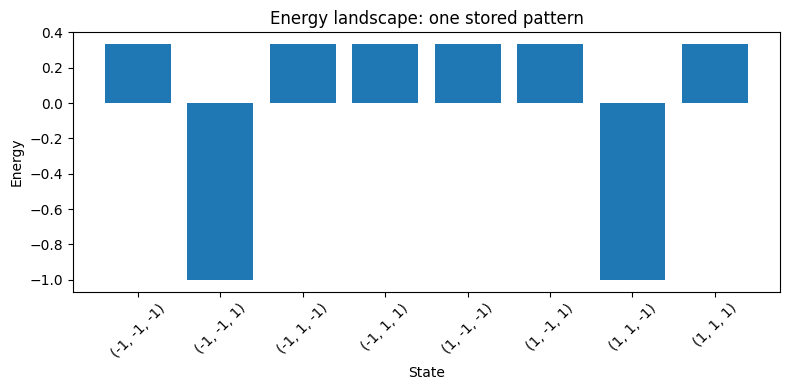

In [6]:
plt.figure(figsize=(8, 4))
plt.bar(range(len(energies_1)), energies_1)
plt.xticks(range(len(states)), [str(tuple(s)) for s in states], rotation=45)
plt.title("Energy landscape: one stored pattern")
plt.xlabel("State")
plt.ylabel("Energy")
plt.tight_layout()
plt.show()

The lowest-energy states correspond to the stored pattern and its sign-reversed partner, as expected in this simple Hopfield setting.

## 3. Recall trajectory from a noisy cue

We now start from a corrupted cue and let the system update asynchronously.

This demonstrates the distinction between:

- **persistent structure**: the weights / energy landscape
- **transient reconstruction**: the recall trajectory through that landscape

In [7]:
cue = np.array([1, -1, -1], dtype=int)
traj_1, trajE_1 = run_until_convergence(cue, W1, max_steps=10, rng=np.random.default_rng(1))

print("Cue:", cue)
print("\nTrajectory:")
for step, (x, e) in enumerate(zip(traj_1, trajE_1)):
    print(f"step {step}: state={x}, energy={e:.3f}")

Cue: [ 1 -1 -1]

Trajectory:
step 0: state=[ 1 -1 -1], energy=0.333
step 1: state=[ 1  1 -1], energy=-1.000
step 2: state=[ 1  1 -1], energy=-1.000


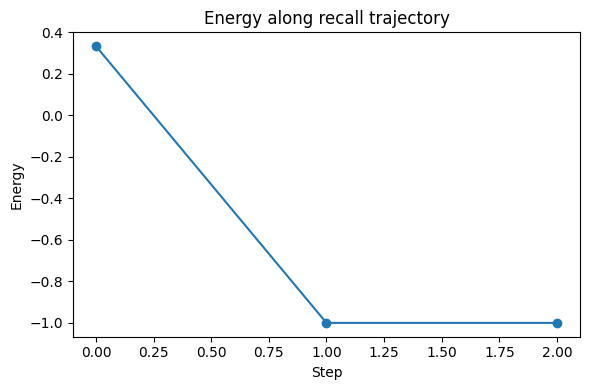

In [8]:
plt.figure(figsize=(6, 4))
plt.plot(range(len(trajE_1)), trajE_1, marker="o")
plt.title("Energy along recall trajectory")
plt.xlabel("Step")
plt.ylabel("Energy")
plt.tight_layout()
plt.show()

**Interpretation:** the trajectory is not stored anywhere. What is stored is the constraint structure \(W\), which shapes the transient evolution of the state.

## 4. Walsh-Hadamard transform of the energy landscape

Now treat the **energy values over all states** as a function on the Boolean hypercube, and apply the Walsh-Hadamard transform.

This lets us inspect the landscape in transform space.

In [9]:
coeffs_1 = walsh_coefficients(energies_1)

print("Walsh coefficients for one-pattern landscape:")
for i, c in enumerate(coeffs_1):
    print(f"index {i:>2} (degree {bitcount(i)}): {c:.3f}")

Walsh coefficients for one-pattern landscape:
index  0 (degree 0): -0.000
index  1 (degree 1): 0.000
index  2 (degree 1): 0.000
index  3 (degree 2): 0.943
index  4 (degree 1): 0.000
index  5 (degree 2): 0.943
index  6 (degree 2): -0.943
index  7 (degree 3): 0.000


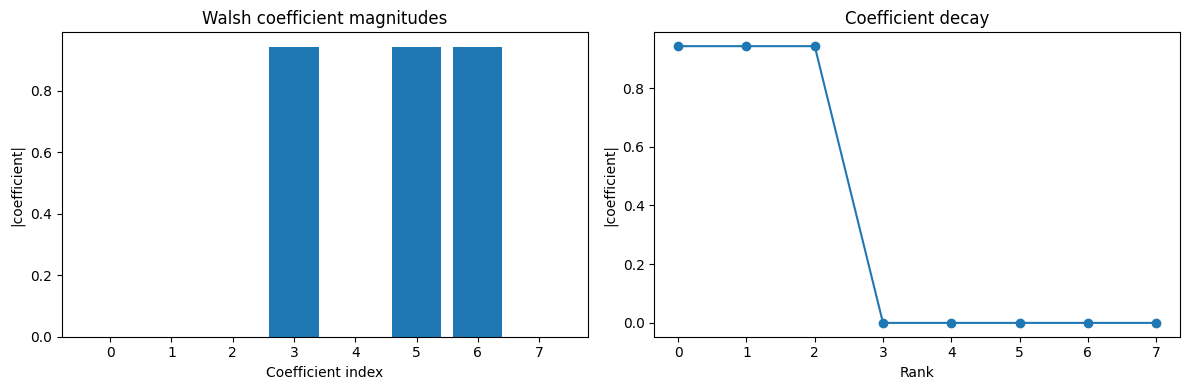

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(coeffs_1)), np.abs(coeffs_1))
axes[0].set_title("Walsh coefficient magnitudes")
axes[0].set_xlabel("Coefficient index")
axes[0].set_ylabel("|coefficient|")

sorted_abs_1 = np.sort(np.abs(coeffs_1))[::-1]
axes[1].plot(sorted_abs_1, marker="o")
axes[1].set_title("Coefficient decay")
axes[1].set_xlabel("Rank")
axes[1].set_ylabel("|coefficient|")

plt.tight_layout()
plt.show()

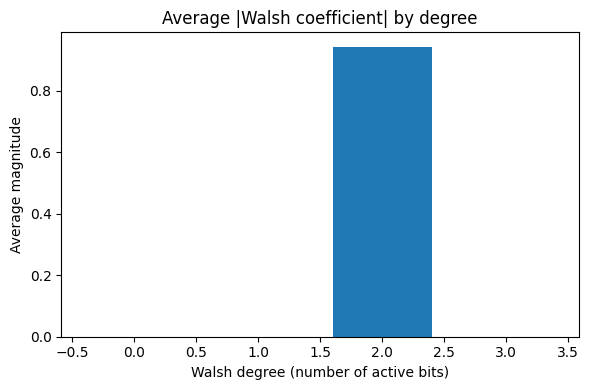

Average coefficient magnitude by degree:
degree 0: 0.000
degree 1: 0.000
degree 2: 0.943
degree 3: 0.000


In [11]:
degrees = np.array([bitcount(i) for i in range(len(coeffs_1))])
degree_means_1 = [np.mean(np.abs(coeffs_1[degrees == d])) for d in range(n + 1)]

plt.figure(figsize=(6, 4))
plt.bar(range(n + 1), degree_means_1)
plt.title("Average |Walsh coefficient| by degree")
plt.xlabel("Walsh degree (number of active bits)")
plt.ylabel("Average magnitude")
plt.tight_layout()
plt.show()

print("Average coefficient magnitude by degree:")
for d, m in enumerate(degree_means_1):
    print(f"degree {d}: {m:.3f}")

This does not by itself prove anything biological. But it *does* provide a concrete transform-domain description of the attractor / energy landscape. Coarser and finer landscape structure can now be discussed in terms of coefficient content.

## 5. Two stored patterns: richer landscape, richer spectrum

Now add a second pattern:

\[
m_2 = (-1, +1, +1).
\]

This should make the energy landscape more structured and the Walsh spectrum correspondingly richer.

In [12]:
pattern_2 = np.array([-1, 1, 1], dtype=int)
W2 = hebbian_weights([pattern_1, pattern_2])

energies_2 = np.array([energy(s, W2) for s in states])
coeffs_2 = walsh_coefficients(energies_2)

print("Weight matrix W2:")
print(W2)

Weight matrix W2:
[[ 0.          0.         -0.66666667]
 [ 0.          0.          0.        ]
 [-0.66666667  0.          0.        ]]


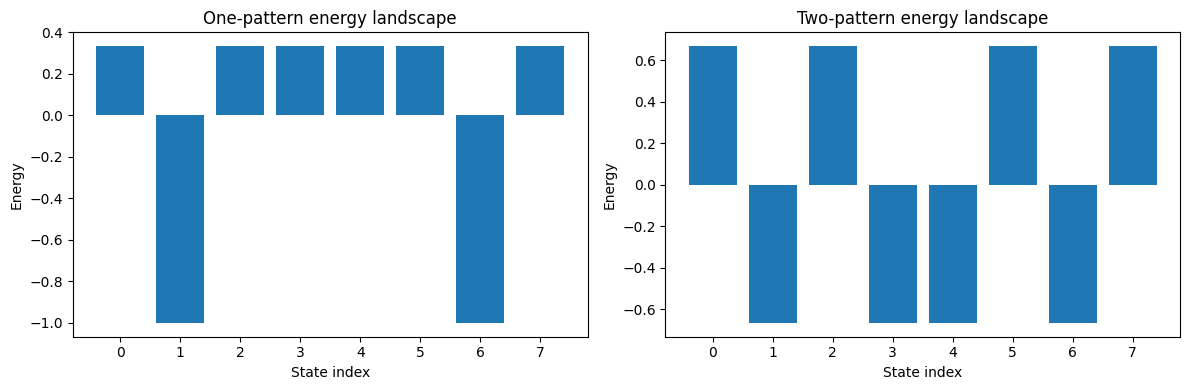

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(energies_1)), energies_1)
axes[0].set_title("One-pattern energy landscape")
axes[0].set_xlabel("State index")
axes[0].set_ylabel("Energy")

axes[1].bar(range(len(energies_2)), energies_2)
axes[1].set_title("Two-pattern energy landscape")
axes[1].set_xlabel("State index")
axes[1].set_ylabel("Energy")

plt.tight_layout()
plt.show()

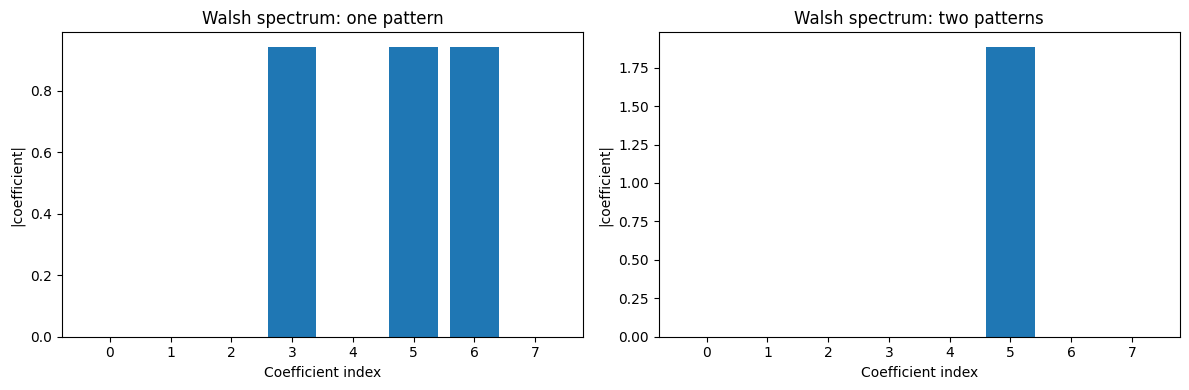

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(coeffs_1)), np.abs(coeffs_1))
axes[0].set_title("Walsh spectrum: one pattern")
axes[0].set_xlabel("Coefficient index")
axes[0].set_ylabel("|coefficient|")

axes[1].bar(range(len(coeffs_2)), np.abs(coeffs_2))
axes[1].set_title("Walsh spectrum: two patterns")
axes[1].set_xlabel("Coefficient index")
axes[1].set_ylabel("|coefficient|")

plt.tight_layout()
plt.show()

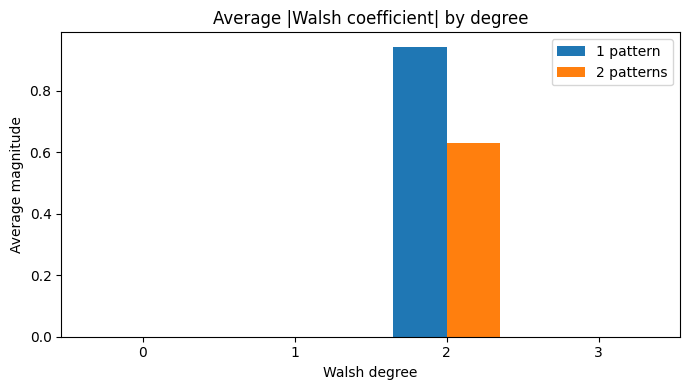

Average coefficient magnitude by degree (two-pattern case):
degree 0: 0.000
degree 1: 0.000
degree 2: 0.629
degree 3: 0.000


In [15]:
degrees = np.array([bitcount(i) for i in range(len(coeffs_2))])
degree_means_2 = [np.mean(np.abs(coeffs_2[degrees == d])) for d in range(n + 1)]

x = np.arange(n + 1)
width = 0.35

plt.figure(figsize=(7, 4))
plt.bar(x - width/2, degree_means_1, width=width, label="1 pattern")
plt.bar(x + width/2, degree_means_2, width=width, label="2 patterns")
plt.title("Average |Walsh coefficient| by degree")
plt.xlabel("Walsh degree")
plt.ylabel("Average magnitude")
plt.xticks(x)
plt.legend()
plt.tight_layout()
plt.show()

print("Average coefficient magnitude by degree (two-pattern case):")
for d, m in enumerate(degree_means_2):
    print(f"degree {d}: {m:.3f}")

The exact details depend on the tiny toy system, but the point is clear: changing memory content changes the landscape, and Walsh space gives a compact way to describe that change.

## 6. Stable-correct versus stable-wrong convergence

This section introduces the key bridge to the later DLMH / constraint-closure work.

We define:

- **stability** = how consistently perturbation trials converge to the same answer
- **accuracy** = how often the final answer matches the intended target

A system can therefore be:

- **stable-correct**
- **unstable**
- **stable-wrong**

To make the stable-wrong case visible, we compare:

1. an **unbiased** one-pattern system
2. a **biased** system with an additional field favouring the wrong sign of the third unit

In [16]:
target = pattern_1.copy()

bias_wrong = np.array([0.0, 0.0, 2.0])  # pushes the third unit toward +1, opposing the target's -1
print("Target pattern:", target)
print("Bias used for stable-wrong demo:", bias_wrong)

Target pattern: [ 1  1 -1]
Bias used for stable-wrong demo: [0. 0. 2.]


In [17]:
records = []

for x0 in states:
    base = run_trials(x0, W1, target, trials=100, steps=5, bias=None, flip_prob=0.2, seed=11)
    biased = run_trials(x0, W1, target, trials=100, steps=5, bias=bias_wrong, flip_prob=0.2, seed=11)
    records.append({
        "x0": x0,
        "base_stability": base["stability"],
        "base_accuracy": base["accuracy"],
        "base_mode": base["mode"],
        "biased_stability": biased["stability"],
        "biased_accuracy": biased["accuracy"],
        "biased_mode": biased["mode"],
    })

print("Trial summary by starting cue:")
for r in records:
    print(
        f"x0={r['x0']} | "
        f"baseline: stability={r['base_stability']:.2f}, accuracy={r['base_accuracy']:.2f}, mode={r['base_mode']} | "
        f"biased: stability={r['biased_stability']:.2f}, accuracy={r['biased_accuracy']:.2f}, mode={r['biased_mode']}"
    )

Trial summary by starting cue:
x0=[-1 -1 -1] | baseline: stability=0.64, accuracy=0.64, mode=[ 1  1 -1] | biased: stability=0.64, accuracy=0.00, mode=[1 1 1]
x0=[-1 -1  1] | baseline: stability=0.61, accuracy=0.39, mode=[-1 -1  1] | biased: stability=0.61, accuracy=0.00, mode=[-1 -1  1]
x0=[-1  1 -1] | baseline: stability=0.83, accuracy=0.83, mode=[ 1  1 -1] | biased: stability=0.83, accuracy=0.00, mode=[1 1 1]
x0=[-1  1  1] | baseline: stability=0.70, accuracy=0.70, mode=[ 1  1 -1] | biased: stability=0.70, accuracy=0.00, mode=[1 1 1]
x0=[ 1 -1 -1] | baseline: stability=0.69, accuracy=0.69, mode=[ 1  1 -1] | biased: stability=0.69, accuracy=0.00, mode=[1 1 1]
x0=[ 1 -1  1] | baseline: stability=0.52, accuracy=0.48, mode=[-1 -1  1] | biased: stability=0.52, accuracy=0.00, mode=[-1 -1  1]
x0=[ 1  1 -1] | baseline: stability=0.88, accuracy=0.88, mode=[ 1  1 -1] | biased: stability=0.88, accuracy=0.00, mode=[1 1 1]
x0=[1 1 1] | baseline: stability=0.79, accuracy=0.79, mode=[ 1  1 -1] | bi

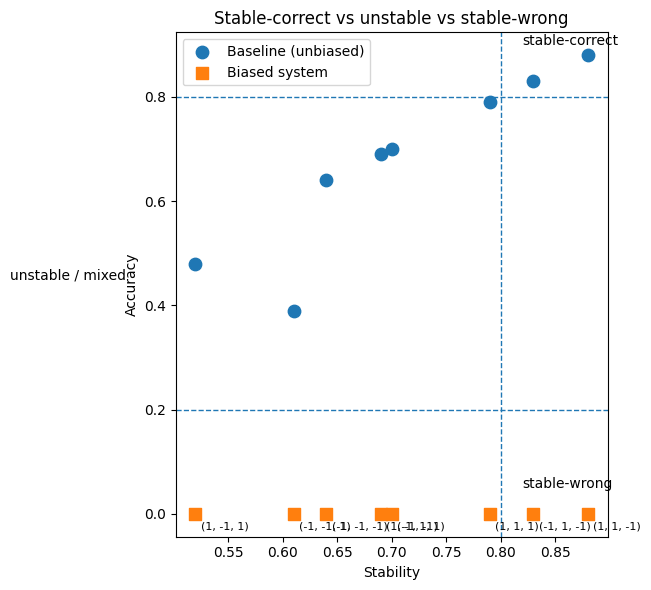

In [18]:
base_points = np.array([(r["base_stability"], r["base_accuracy"]) for r in records])
biased_points = np.array([(r["biased_stability"], r["biased_accuracy"]) for r in records])

plt.figure(figsize=(7, 6))
plt.scatter(base_points[:, 0], base_points[:, 1], s=80, label="Baseline (unbiased)")
plt.scatter(biased_points[:, 0], biased_points[:, 1], s=80, marker="s", label="Biased system")

for r in records:
    plt.annotate(str(tuple(r["x0"])), (r["biased_stability"] + 0.005, r["biased_accuracy"] - 0.03), fontsize=8)

plt.axvline(0.8, linestyle="--", linewidth=1)
plt.axhline(0.2, linestyle="--", linewidth=1)
plt.axhline(0.8, linestyle="--", linewidth=1)

plt.text(0.82, 0.9, "stable-correct", fontsize=10)
plt.text(0.82, 0.05, "stable-wrong", fontsize=10)
plt.text(0.35, 0.45, "unstable / mixed", fontsize=10)

plt.xlabel("Stability")
plt.ylabel("Accuracy")
plt.title("Stable-correct vs unstable vs stable-wrong")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
print("Examples of stable-wrong convergence in the biased system:")
for r in records:
    if r["biased_stability"] >= 0.8 and r["biased_accuracy"] <= 0.2:
        print(f"start {r['x0']} -> dominant output {r['biased_mode']} "
              f"(stability={r['biased_stability']:.2f}, accuracy={r['biased_accuracy']:.2f})")

Examples of stable-wrong convergence in the biased system:
start [-1  1 -1] -> dominant output [1 1 1] (stability=0.83, accuracy=0.00)
start [ 1  1 -1] -> dominant output [1 1 1] (stability=0.88, accuracy=0.00)


This is the crucial point:

> **Low output variance does not imply correctness.**

A system can converge very consistently and yet converge to the wrong answer.  
That is the minimal toy version of a **stable incorrect attractor**.

### Formal Statement

Let S(x) = stability (response invariance)
Let A(x) = accuracy (agreement with ground truth)

Then:

- Stable correct: S high, A high
- Unstable: S low
- Stable wrong: S high, A low

This demonstrates that internal consistency does not imply correctness.

## 7. Final observations

### What this notebook has shown

1. A tiny distributed memory system can be written as a persistent **constraint / energy landscape**.
2. Recall proceeds via a **trajectory** through that landscape.
3. The landscape can be analysed in **Walsh space**.
4. Adding memory content changes the energy landscape and its Walsh spectrum.
5. Stability and correctness are distinct quantities.
6. A system can be **stable-wrong** as well as **stable-correct**.

### Why this matters

This provides a compact mathematical bridge between:

- classical attractor dynamics,
- transform-domain analysis,
- DLMH-style trajectory-based reconstruction,
- and the later distinction between **consistent correctness** and **consistent error**.